# Getting started

Solving an LP and a QP on the GPU, and checking both against a reference solver.

Every claim below is asserted. If cuProx disagrees with the reference, this notebook fails to execute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cuprox

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
GPU = "#76B900"
REF = "#546778"

assert cuprox.__cuda_available__, (
    "This notebook must run against a CUDA build. Install with `pip install .` "
    "from the repository root; installing python/ alone does not build the "
    "extension."
)
from cuprox import _core
print(f"cuProx {cuprox.__version__} on {_core.get_device_name()}")

cuProx 0.2.0 on NVIDIA RTX A6000


## A linear program

```
maximise  5x + 4y
s.t.      x + 2y <= 10
          3x +  y <= 15
          x, y   >= 0
```
The optimum is at the intersection of the two constraints: `x = 4, y = 3`, objective `32`.

In [2]:
model = cuprox.Model()
x = model.add_var(lb=0, name="x")
y = model.add_var(lb=0, name="y")
model.add_constr(x + 2 * y <= 10)
model.add_constr(3 * x + y <= 15)
model.maximize(5 * x + 4 * y)

result = model.solve()
print(f"status    {result.status.value}")
print(f"objective {result.objective:.6f}   (exact: 32)")
print(f"x, y      {result.x[0]:.6f}, {result.x[1]:.6f}   (exact: 4, 3)")

assert result.status is cuprox.Status.OPTIMAL
assert abs(result.objective - 32.0) < 1e-3
np.testing.assert_allclose(result.x, [4.0, 3.0], atol=1e-3)

status    optimal
objective 31.999844   (exact: 32)
x, y      4.000106, 2.999828   (exact: 4, 3)


## A quadratic program, checked against OSQP

In matrix form, minimising `½ xᵀPx + qᵀx` subject to `l ≤ Ax ≤ u` and `lb ≤ x ≤ ub`.

In [3]:
from scipy import sparse

rng = np.random.default_rng(0)
n, m = 200, 100
M = sparse.random(n, n, density=0.1, random_state=0, format="csr")
P = (M @ M.T + sparse.identity(n) * 0.1).tocsr()
A = sparse.random(m, n, density=0.1, random_state=1, format="csr")
q = rng.standard_normal(n)
l, u = -np.ones(m), np.ones(m)
lb, ub = np.full(n, -5.0), np.full(n, 5.0)

res = cuprox.solve(c=q, P=P, A=A, constraint_l=l, constraint_u=u,
                   lb=lb, ub=ub,
                   params={"tolerance": 1e-8, "max_iterations": 200_000})
print(f"cuProx   {res.objective:.8f}  ({res.iterations} iterations)")

cuProx   -47.27858453  (150 iterations)


In [4]:
import osqp

# OSQP has no separate variable bounds, so the box goes in as rows of A --
# the same encoding cuProx uses internally.
A_aug = sparse.vstack([A, sparse.identity(n, format="csc")], format="csc")
prob = osqp.OSQP()
prob.setup(P=P.tocsc(), q=q, A=A_aug,
           l=np.concatenate([l, lb]), u=np.concatenate([u, ub]),
           verbose=False, eps_abs=1e-9, eps_rel=1e-9, max_iter=200_000)
ref = prob.solve()

print(f"OSQP     {ref.info.obj_val:.8f}")
rel = abs(res.objective - ref.info.obj_val) / abs(ref.info.obj_val)
print(f"relative difference {rel:.2e}")

assert rel < 1e-5
assert np.all(np.asarray(res.x) >= lb - 1e-6)
assert np.all(np.asarray(res.x) <= ub + 1e-6)
Ax = A @ np.asarray(res.x)
assert np.all(Ax >= l - 1e-4) and np.all(Ax <= u + 1e-4)

OSQP     -47.27858453
relative difference 9.15e-11


## Where the GPU actually helps

cuProx is matrix-free: an iteration costs a few sparse mat-vecs, and that cost does not depend on the sparsity *pattern*. OSQP factorises, which is excellent until the factor fills in.

So the interesting variable is not problem size but how badly the factorisation fills in. Below, the same sizes are solved with a **banded** `A` (kind to a direct method) and a **random** `A` (not).

In [5]:
import time

def make(n, kind, band=3, nnz_row=8, seed=0):
    rng = np.random.default_rng(seed)
    m = n // 2
    P = sparse.diags([rng.uniform(0.5, 1.5, n)]
                     + [rng.uniform(-0.3, 0.3, n) for _ in range(band)],
                     [0] + list(range(1, band + 1)), shape=(n, n), format="csr")
    P = (P + P.T).tocsr() + sparse.identity(n, format="csr")
    rows = np.repeat(np.arange(m), nnz_row)
    if kind == "banded":
        cols = (np.tile(np.arange(nnz_row), m)
                + np.repeat(np.arange(m), nnz_row)) % n
    else:
        cols = rng.integers(0, n, size=m * nnz_row)
    A = sparse.csr_matrix((rng.standard_normal(m * nnz_row), (rows, cols)),
                          shape=(m, n))
    return P, rng.standard_normal(n), A, -np.ones(m), np.ones(m)

def best(fn, reps=2):
    fn()
    out = []
    for _ in range(reps):
        t0 = time.perf_counter()
        fn()
        out.append(time.perf_counter() - t0)
    return min(out)

# Kept small deliberately: with a random A, OSQP's factorisation fills in
# so badly that n = 20,000 takes minutes, which is the very effect this
# cell exists to show. Two sizes are enough to show it.
sizes = [1_000, 5_000]
timings = {}
for kind in ("banded", "random"):
    gpu, cpu = [], []
    for n in sizes:
        P, q, A, l, u = make(n, kind)
        lb, ub = np.full(n, -10.0), np.full(n, 10.0)
        gpu.append(best(lambda: cuprox.solve(
            c=q, P=P, A=A, constraint_l=l, constraint_u=u, lb=lb, ub=ub,
            params={"tolerance": 1e-4, "max_iterations": 4000})))
        A_aug = sparse.vstack([A, sparse.identity(n, format="csc")], format="csc")
        la, ua = np.concatenate([l, lb]), np.concatenate([u, ub])
        Pc = P.tocsc()
        def run_osqp(Pc=Pc, q=q, A_aug=A_aug, la=la, ua=ua):
            pr = osqp.OSQP()
            pr.setup(P=Pc, q=q, A=A_aug, l=la, u=ua, verbose=False,
                     eps_abs=1e-4, eps_rel=1e-4)
            return pr.solve()
        cpu.append(best(run_osqp))
    timings[kind] = (gpu, cpu)

for kind, (gpu, cpu) in timings.items():
    print(f"{kind:>7}  " + "  ".join(
        f"n={n}: {c/g:5.2f}x" for n, g, c in zip(sizes, gpu, cpu)))

 banded  n=1000:  0.02x  n=5000:  0.13x
 random  n=1000:  0.70x  n=5000: 72.38x


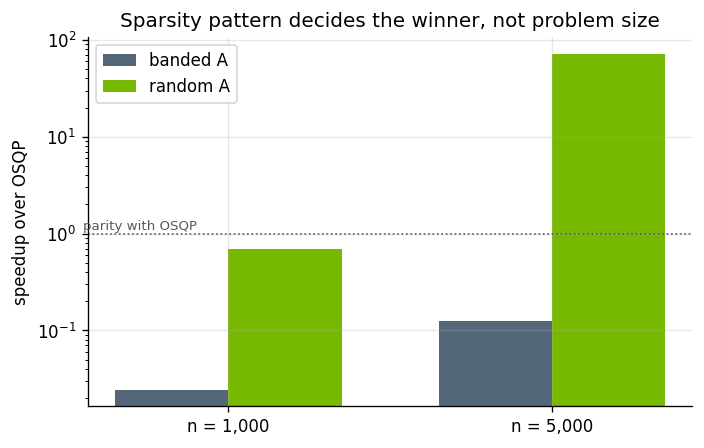

In [6]:
# Bars rather than joined points: two sizes is enough to show the
# effect, but a line through two points on log-log axes would claim a
# slope that two measurements cannot support.
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(sizes))
width = 0.35
for i, (kind, colour) in enumerate((("banded", REF), ("random", GPU))):
    gpu, cpu = timings[kind]
    ax.bar(x + (i - 0.5) * width, [c / g for c, g in zip(cpu, gpu)],
           width, color=colour, label=f"{kind} A")
ax.axhline(1.0, color="0.35", lw=1, ls=":")
ax.text(-0.45, 1.1, "parity with OSQP", color="0.35", fontsize=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"n = {n:,}" for n in sizes])
ax.set_ylabel("speedup over OSQP")
ax.set_title("Sparsity pattern decides the winner, not problem size")
ax.legend()
fig.savefig("benchmark_sparsity.png")
plt.show()

The two curves separate at the same problem sizes. That is the whole story: a matrix-free first-order method is indifferent to fill-in, and a direct method is not.

For small or well-structured problems a good CPU solver is the better tool, and cuProx says so in its README.